# Lecture 0 - Introduction to QuTiP

QuTiP is a python package for calculations and numerical simulations of quantum systems.

It includes facilities for representing and doing calculations with quantum objects such state vectors (wavefunctions), as bras/kets/density matrices, quantum operators of single and composite systems, and superoperators (useful for defining master equations).

It also includes solvers for a time-evolution of quantum systems, according to: Schrodinger equation, von Neuman equation, master equations, Floquet formalism, Monte-Carlo quantum trajectors, experimental implementations of the stochastic Schrodinger/master equations.

For more information see the project web site at [qutip.org](https://qutip.org/), and the [QuTiP documentation](https://qutip.readthedocs.io/en/latest/index.html).



## Import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image
from qutip import *

# Set a parameter to see animations in line
from matplotlib import rc
rc('animation', html='jshtml')

%matplotlib inline

## Quantum object class: ```qobj```

At the heart of the QuTiP package is the ```Qobj``` class, which is used for representing quantum object such as states and operator.

The ```Qobj``` class contains all the information required to describe a quantum system, such as its matrix representation, composite structure and dimensionality.

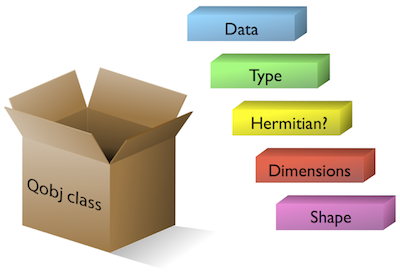

In [2]:
Image(filename="images/qobj.png")

### Creating and inspecting quantum objects

We can create a new quantum object using the ```Qobj``` class constructor, like this:

In [3]:
q = Qobj([[1], [0]])

q

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[1.]
 [0.]]

Here we passed python list as an argument to the class constructor. The data in this list is used to construct the matrix representation of the quantum objects, and the other properties of the quantum object is by default computed from the same data.

We can inspect the properties of a ```Qobj``` instance using the following class method:

In [4]:
# the dimension, or composite Hilbert state space structure
q.dims

[[2], [1]]

In [5]:
# The shape of the matrix data representation
q.shape

(2, 1)

In [6]:
# the martrix data itself. in sparse matrix format
q.data

Dense(shape=(2, 1), fortran=True)

In [7]:
q.full()      # get the dense matrix representation

array([[1.+0.j],
       [0.+0.j]])

In [8]:
q.isherm, q.type

(False, 'ket')

### Using ```Qobj``` instances for calculations

With ```Qobj``` instances we can do arithmetic and apply a number of different operations using class methods:

In [9]:
sy = Qobj([[0, -1j], [1j, 0]])  # The sigma-y Pauli operator
sy

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

In [10]:
sz = Qobj([[1, 0], [0, -1]])     # the sigma-z Pauli operator

sz

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]

In [11]:
# Some arithmetic with quantum objects

H = 1.0 * sz + 0.1 * sy

print("Qubit Hamiltonian = \n")
H

Qubit Hamiltonian = 



Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 1.+0.j   0.-0.1j]
 [ 0.+0.1j -1.+0.j ]]

Example of modifying quantum objects using the ```Qobj``` methods:

In [12]:
# The hermitian conjugate
sy.dag()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]

In [13]:
# The trace
H.tr()

0.0

In [14]:
# Eigen energies
H.eigenenergies()

array([-1.00498756,  1.00498756])

For a complete list of methods and properties of the ```Qobj``` class, see the [QuTip documentation](https://qutip.readthedocs.io/en/latest/index.html) or try ```help(Qobj)``` or ```dir(Qobj)```.

## States and operators

Normally we do not need to create ```Qobj``` instances from stratch, using its constructor and passing its matrix represantation as argument. Instead we can use functions in QuTiP that generates common states and operators for us. Here are some examples of built-in state functions:

### State Vectors

In [15]:
# Fundamental basis states (Fock states of oscillator modes)

N = 2   # number of states in Hilbert space
n = 1   # the state that will be occupied

basis(N, n)     # Equivalent to fock(N, n)

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [1.]]

This creates a column vector representing "the particle is definitely in state 1":

$\begin{pmatrix} 1 \\ 0 \end{pmatrix}$
- Top number (0) = probability amplitude for being in state 0
- Bottom number (1) = probability amplitude for being in state 1

| Concept             | Analogy                                                  |
| ------------------- | -------------------------------------------------------- |
| **Fock state**      | A "pure" quantum state with exactly *n* particles/quanta |
| **Oscillator mode** | Like a vibrating guitar string with specific harmonics   |
| **Hilbert space**   | All possible quantum configurations of your system       |


If this is light (photons):
- N=2 means we only consider 0 or 1 photon existing
- n=1 means we have exactly 1 photon — not a superposition, not uncertain, just precisely one


| Code          | Meaning                                                            |
| ------------- | ------------------------------------------------------------------ |
| `basis(2, 0)` | $\begin{pmatrix} 1 \\ 0 \end{pmatrix}$ — "definitely empty"        |
| `basis(2, 1)` | $\begin{pmatrix} 0 \\ 1 \end{pmatrix}$ — "definitely one particle" |



In [16]:
fock(4, 2)  # Another Example

Quantum object: dims=[[4], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.]
 [0.]
 [1.]
 [0.]]

In [17]:
# A coherent state
coherent(N=10, alpha=1.0)

Quantum object: dims=[[10], [1]], shape=(10, 1), type='ket', dtype=Dense
Qobj data =
[[0.60653066]
 [0.60653066]
 [0.42888194]
 [0.24761511]
 [0.12380753]
 [0.0553686 ]
 [0.02260303]
 [0.00854887]
 [0.00299672]
 [0.00110007]]

**```Why Coherent States Are Special```**


| Property      | Fock State \|n⟩          | Coherent State \|$\alpha$⟩             |
| ------------- | ------------------------ | ------------------------------------ |
| Photon number | **Exact** (certain)      | **Uncertain** (Poisson distribution) |
| Phase         | **Completely uncertain** | **Well-defined**                     |
| Behavior      | Most "quantum"           | Most "classical"                     |
| Example       | Single-photon source     | Laser light                          |


Coherent states are the "best of both worlds" — quantum enough to be fundamental, classical enough to describe everyday laser light!

$$|\alpha\rangle = e^{-|\alpha|^2/2} \sum_{n=0}^{N-1} \frac{\alpha^n}{\sqrt{n!}} |n\rangle$$

Or in numbers for α = 1.0:

$$|1.0\rangle \approx 0.61|0\rangle + 0.61|1\rangle + 0.43|2\rangle + 0.25|3\rangle + ...$$

### Density matrices

The **density matrix** ρ is the most general way to describe a quantum state. It handles:
- **Pure states** (traditional wavefunctions)
- **Mixed states** (statistical ensembles / imperfect knowledge)

---

```For a Pure State |ψ⟩```
$$\rho = |\psi\rangle\langle\psi|$$

**Example:** If $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$, then:
$$\rho = \begin{pmatrix} |\alpha|^2 & \alpha\beta^* \\ \alpha^*\beta & |\beta|^2 \end{pmatrix}$$

```For a Mixed State (Statistical Mixture)```
$$\rho = \sum_i p_i |\psi_i\rangle\langle\psi_i|$$

Where $p_i$ = classical probability of being in state $|\psi_i\rangle$

---

```Key Properties```

| Property | Mathematical Form | Meaning |
|----------|-------------------|---------|
| **Hermitian** | $\rho = \rho^\dagger$ | Real eigenvalues (probabilities) |
| **Positive semi-definite** | $\rho \geq 0$ | All eigenvalues ≥ 0 |
| **Unit trace** | $\text{Tr}(\rho) = 1$ | Total probability = 1 |
| **Purity** | $\text{Tr}(\rho^2) = 1$ (pure), $<1$ (mixed) | How "quantum" vs classical |


In [18]:
# a fock state as density matrix

fock_dm(5, 2)   # 5 = hilbert space size, 2 = state that is occupied


# 5 = Hilbert space size (states |0⟩ through |4⟩)
# 2 = the Fock state |2⟩ is occupied (3rd state, since counting starts at 0)
# All other entries = 0: Zero probability for any other state
# Diagonal only: Pure state with no quantum coherence
# Purity = 1: Tr(ρ)^2 = 1 => completely pure

# The below matrix represent:
# rho = |2><2|

# This is a pure state density matrix —> the simplest possible case where you have 100% certainty about the quantum state.

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

In [19]:
# coherent state as density matrix
coherent_dm(N=8, alpha=1.0)

# N=8 => Hilbert space truncated to 8 states (|0⟩ through |7⟩)
# alpha=1.0 => coherent state with average photon number ∣α∣^2=1 

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=True
Qobj data =
[[3.67879439e-01 3.67879455e-01 2.60129900e-01 1.50187300e-01
  7.50858773e-02 3.36199110e-02 1.35485515e-02 5.77267786e-03]
 [3.67879455e-01 3.67879470e-01 2.60129911e-01 1.50187306e-01
  7.50858804e-02 3.36199124e-02 1.35485520e-02 5.77267810e-03]
 [2.60129900e-01 2.60129911e-01 1.83939513e-01 1.06198399e-01
  5.30937031e-02 2.37728537e-02 9.58026722e-03 4.08189737e-03]
 [1.50187300e-01 1.50187306e-01 1.06198399e-01 6.13141770e-02
  3.06539153e-02 1.37253761e-02 5.53121524e-03 2.35670388e-03]
 [7.50858773e-02 7.50858804e-02 5.30937031e-02 3.06539153e-02
  1.53253712e-02 6.86197771e-03 2.76532136e-03 1.17822997e-03]
 [3.36199110e-02 3.36199124e-02 2.37728537e-02 1.37253761e-02
  6.86197771e-03 3.07246966e-03 1.23818035e-03 5.27555757e-04]
 [1.35485515e-02 1.35485520e-02 9.58026722e-03 5.53121524e-03
  2.76532136e-03 1.23818035e-03 4.98976640e-04 2.12600691e-04]
 [5.77267786e-03 5.77267810e

**```Matrix Structure of Coherent State Density Matrix```**

```General Formula```

$$\rho_{nm} = \langle n|\alpha\rangle\langle\alpha|m\rangle = e^{-|\alpha|^2} \frac{\alpha^n (\alpha^*)^m}{\sqrt{n!m!}}$$

```For alpha = 1.0 (Real)```

$$\rho_{nm} = e^{-1} \frac{1}{\sqrt{n!m!}} = \frac{1}{e\sqrt{n!m!}}$$

```Matrix Elements Pattern```

$$\rho = 
\begin{pmatrix} 
|C_0|^2 & C_0 C_1^* & C_0 C_2^* & C_0 C_3^* & \cdots \\
C_1 C_0^* & |C_1|^2 & C_1 C_2^* & C_1 C_3^* & \cdots \\
C_2 C_0^* & C_2 C_1^* & |C_2|^2 & C_2 C_3^* & \cdots \\
C_3 C_0^* & C_3 C_1^* & C_3 C_2^* & |C_3|^2 & \cdots \\
\vdots & \vdots & \vdots & \vdots & \ddots
\end{pmatrix}$$

Where $C_n = e^{-|\alpha|^2/2} \frac{\alpha^n}{\sqrt{n!}}$

```Explicit Values for alpha = 1.0```

$$\rho \approx
\begin{pmatrix} 
0.368 & 0.368 & 0.260 & 0.150 & 0.075 & 0.034 & \cdots \\
0.368 & 0.368 & 0.260 & 0.150 & 0.075 & 0.034 & \cdots \\
0.260 & 0.260 & 0.184 & 0.106 & 0.053 & 0.024 & \cdots \\
0.150 & 0.150 & 0.106 & 0.061 & 0.031 & 0.014 & \cdots \\
0.075 & 0.075 & 0.053 & 0.031 & 0.015 & 0.007 & \cdots \\
0.034 & 0.034 & 0.024 & 0.014 & 0.007 & 0.003 & \cdots \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \ddots
\end{pmatrix}$$

```Key Structural Properties```

| Property | Mathematical Form |
|----------|-----------------|
| **Hermitian** | $\rho_{nm} = \rho_{mn}^*$ |
| **Factorizable** | $\rho_{nm} = C_n C_m^*$ (outer product) |
| **Rank-1** | Single non-zero eigenvalue ($\lambda = 1$) |
| **Pure state** | $\text{Tr}(\rho^2) = 1$ |
| **Positive semi-definite** | All eigenvalues $\geq 0$ |


Non-zero off-diagonals: Quantum coherence between different photon numbers
Decreasing values away from corner: Higher photon numbers contribute less
All entries positive: Characteristic of coherent states
Purity ≈ 1: Also a pure state (just written in density matrix form)


```Critical Comparison```
| **Property**                  | **Fock State $\|2\rangle\langle 2\|$** | **Coherent State $\|\alpha\rangle\langle\alpha\|$**   |
| ------------------------- | ---------------------------------- | ------------------------------------------------- |
| **Photon number**         | **Exact** (2 photons)              | **Uncertain** (Poisson distribution, $\bar{n}=1$) |
| **Phase**                 | **Completely undefined**           | **Well-defined**                                  |
| **Diagonal elements**     | Single `1`                         | Poisson distribution $P_n = e^{-1}\frac{1^n}{n!}$ |
| **Off-diagonal elements** | All **zero**                       | **Non-zero** (coherence)                          |
| **Physical example**      | Single-photon source               | **Laser light**                                   |
| **Nature**                | Most "quantum"                     | Most "classical" quantum state                    |


Both density matrices represent pure states:
- Fock: ρ=∣2⟩⟨2∣  — pure in number basis
- Coherent: ρ=∣α⟩⟨α∣  — pure but superposition in number basis


In [20]:
# Thermal State
n = 1  # average number of thermal photons
thermal_dm(8, n)

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0.50196078 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.25098039 0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.1254902  0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.0627451  0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.03137255 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.01568627
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.00784314 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.00392157]]

### Operators

#### Qubit (two-level system) Operator

In [21]:
# Pauli sigma x
sigmax()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

In [22]:
# Pauli sigma y
sigmay()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]

In [25]:
# Pauli sigma z
sigmaz()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]

#### Harmonic oscillator operators

In [29]:
# Annihilation operator

destroy(N=8)    # N = number of fock states included in the Hilbert space

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         1.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         1.41421356 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         1.73205081 0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         2.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         2.23606798
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  2.44948974 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         2.64575131]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

In [32]:
# Creation operator

create(N=8)     # Equivalent to destroy(8).dag()
# There is typo error in QuTiP original Documentation.

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [1.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         1.41421356 0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         1.73205081 0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         2.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         2.23606798 0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         2.44948974
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  2.64575131 0.        ]]

In [33]:
# The position operator is easily constructed from the annihilation operator
a = destroy(8)

x = a + a.dag()

x

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0.         1.         0.         0.         0.         0.
  0.         0.        ]
 [1.         0.         1.41421356 0.         0.         0.
  0.         0.        ]
 [0.         1.41421356 0.         1.73205081 0.         0.
  0.         0.        ]
 [0.         0.         1.73205081 0.         2.         0.
  0.         0.        ]
 [0.         0.         0.         2.         0.         2.23606798
  0.         0.        ]
 [0.         0.         0.         0.         2.23606798 0.
  2.44948974 0.        ]
 [0.         0.         0.         0.         0.         2.44948974
  0.         2.64575131]
 [0.         0.         0.         0.         0.         0.
  2.64575131 0.        ]]

Using ```Qobj``` instances we can check some well known commutation relations:

In [35]:
def commulator(op1, op2):
    return op1 * op2 - op2 * op1

| Result          | Meaning                                      |
| --------------- | -------------------------------------------- |
| $[A, B] = 0$    | Operators **commute** — order doesn't matter |
| $[A, B] \neq 0$ | Operators **don't commute** — order matters! |


In quantum mechanics, **non-commuting operators** represent **incompatible observables**

| Commutator                 | Result       | Physical Meaning                                  |
| -------------------------- | ------------ | ------------------------------------------------- |
| $[a, a^\dagger]$           | $1$          | Annihilation and creation operators don't commute |
| $[a, a]$                   | $0$          | Any operator commutes with itself                 |
| $[a^\dagger a, a]$         | $-a$         | Number operator and annihilation                  |
| $[a^\dagger a, a^\dagger]$ | $+a^\dagger$ | Number operator and creation                      |
| $[x, p]$                   | $i\hbar$     | Position and momentum                             |

Where $a, a\dagger$ are the annihilation and creation operators.

| Application               | How Commutator Helps                                 |
| ------------------------- | ---------------------------------------------------- |
| **Uncertainty relations** | Calculate minimum uncertainties                      |
| **Dynamics**              | Heisenberg equation: $i\hbar \frac{dA}{dt} = [A, H]$ |
| **Algebra structure**     | Define Lie algebras, symmetries                      |
| **Diagonalization**       | Find simultaneous eigenstates (only if $[A,B]=0$)    |
| **Ordering problems**     | Normal ordering, squeezing operators                 |


```Summary```:

The commutator is the heartbeat of quantum mechanics. It quantifies how much two operations "interfere" with each other, directly encoding the fundamental uncertainty and non-commutativity that distinguishes quantum physics from classical physics.

In [41]:
a = destroy(5)

commutator(a, a.dag())

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dia, isherm=True
Qobj data =
[[ 1.  0.  0.  0.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0. -4.]]

**Ops**... The result is not identity! Why? Because we have truncated the Hilbert space. But that's OK as long as the highest Fock state isn't involved in the dynamics in our truncated Hilbert space. If it is, the approximation that the truncation introduces might be a problem.

$[x, p] = i$

In [42]:
x = (a + a.dag()) / np.sqrt(2)
p = -1j * (a - a.dag()) / np.sqrt(2)

In [43]:
commutator(x, p)

Quantum object: dims=[[5], [5]], shape=(5, 5), type='oper', dtype=Dia, isherm=False
Qobj data =
[[0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+1.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+1.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.-4.j]]

Same issue with the truncated Hilbert space, but otherwise OK.

Let's try some Pauli spin inequalities

$[\sigma_x, \sigma_y] = 2i\sigma_z$

In [47]:
commutator(sigmax(), sigmay()) - 2j * sigmaz()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 0.]
 [0. 0.]]

$i\sigma_x\sigma_y\sigma_z =  1$

In [48]:
-1j * sigmax() * sigmay() * sigmaz()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0.]
 [0. 1.]]

$\sigma_x ^ 2 = \sigma_y ^ 2 = \sigma_z ^ 2 = 1$

In [50]:
sigmax() ** 2 == sigmay() ** 2  == sigmaz() ** 2 == qeye(2)

# Where qeye(2) => Quantum Eye (Identity Operator)
# This is 2x2 Identity Matrix

True

| Name  | Meaning                                        |
| ----- | ---------------------------------------------- |
| `q`   | **Q**uantum                                    |
| `eye` | **Eye**dentity (from NumPy's `eye()` function) |


NumPy has ```np.eye(n)``` for identity matrices. QuTiP adds ```q``` to indicate it's for quantum objects.